In [1]:
#!/usr/bin/env python3
"""Benchmark mHC fused kernels: cutile vs tilelang vs triton.

Forward and backward are benchmarked separately. n (mHC streams) is fixed at 4;
batch is fixed at 1; seqlen varies (kernels depend only on s*b).

Ops benchmarked (each fwd + bwd):
  sinkhorn        - Sinkhorn-Knopp projection on n x n matrices
  aggregate       - (s,b,n,C) x (s,b,n) -> (s,b,C)
  expand_combine  - H_res @ residual + H_post * x
  projection      - (M,K) @ weight^T; each impl stops at its natural boundary

Per-impl backward call site:
  cutile    - low-level `_cutile_*_bwd` kernels
  tilelang  - JIT backward kernels directly
  triton    - `torch.autograd.grad` (the exposed path)
"""
import argparse
import os
import sys

import torch
import triton
import triton.testing

from cutile_kernels.cutile_kernels import (
    fused_sinkhorn as cutile_sinkhorn,
    fused_h_aggregate as cutile_aggregate,
    fused_h_post_bda as cutile_expand_combine,
    fused_proj_rms as cutile_proj_rms,
    is_cutile_available,
    _cutile_sinkhorn_fwd,
    _cutile_sinkhorn_bwd,
    _cutile_h_aggregate_bwd,
    _cutile_h_post_bda_bwd,
    _cutile_proj_rms_fwd,
    _cutile_proj_rms_bwd,
)
from tilelang_kernels.sinkhorn_kernel import (
    _mhc_sinkhorn_fwd as tl_sinkhorn_jit,
    _mhc_sinkhorn_bwd as tl_sinkhorn_bwd_jit,
)
from tilelang_kernels.pre_apply_mix_kernel import (
    _mhc_pre_apply_mix_fwd as tl_pre_apply_mix_jit,
    _mhc_pre_apply_mix_bwd as tl_pre_apply_mix_bwd_jit,
)
from tilelang_kernels.post_kernel import (
    mhc_post_fwd as tl_post_fwd,
    mhc_post_bwd as tl_post_bwd,
)
from tilelang_kernels.norm_fn_kernel import (
    _mhc_pre_norm_fn_fwd_mul as tl_norm_fn_mul_jit,
    _mhc_pre_norm_fn_fwd_norm as tl_norm_fn_norm_jit,
    _mhc_pre_norm_fn_bwd_norm as tl_norm_fn_bwd_norm_jit,
    _mhc_pre_norm_fn_bwd_mul as tl_norm_fn_bwd_mul_jit,
)
from triton_kernels.mhc_ops import (
    mhc_fused_sinkhorn as triton_sinkhorn,
    mhc_fused_aggregate as triton_aggregate,
    mhc_fused_expand_combine as triton_expand_combine,
    mhc_fused_projection as triton_projection,
)

In [2]:
HIDDEN = 2048
DTYPE = torch.bfloat16

DEVICE = 'cuda'
N_STREAMS = 4
BATCH = 1
SINKHORN_ITERS = 20
SINKHORN_EPS = 1e-6
QUANTILES = [0.5, 0.2, 0.8]
PROVIDERS = ['cutile', 'tilelang', 'triton']
SEQLENS = [512, 1024, 2048, 4096, 8192, 16384]


In [3]:
# ---------------------------------------------------------------------------
# Tilelang JIT caches
# ---------------------------------------------------------------------------
_tl_cache: dict = {}


def _tl_get(factory, *key):
    full_key = (id(factory),) + key
    if full_key not in _tl_cache:
        _tl_cache[full_key] = factory(*key)
    return _tl_cache[full_key]


def _pick_token_block(num_tokens, preferred=32):
    for k in range(min(preferred, num_tokens), 0, -1):
        if num_tokens % k == 0:
            return k
    return 1

In [4]:
# ===========================================================================
# Forward builders (each returns a zero-arg callable for do_bench)
# ===========================================================================
def build_sinkhorn_fwd(provider, s, b, n, iters):
    torch.manual_seed(0)
    h_res = torch.randn(s, b, n, n, device=DEVICE, dtype=torch.float32)
    if provider == 'cutile':
        return lambda: cutile_sinkhorn(h_res, iters)
    if provider == 'triton':
        return lambda: triton_sinkhorn(h_res, n=n, recompute_hist=True, iters=iters)
    if provider == 'tilelang':
        num_tokens = s * b
        tb = _pick_token_block(num_tokens)
        kernel = _tl_get(tl_sinkhorn_jit, n, tb, iters, SINKHORN_EPS)
        inp = h_res.view(num_tokens, n, n)
        out = torch.empty_like(inp)
        return lambda: kernel(inp, out)
    raise ValueError(provider)


def build_aggregate_fwd(provider, s, b, n, C, dtype):
    torch.manual_seed(0)
    x_nC = torch.randn(s, b, n, C, device=DEVICE, dtype=dtype)
    h_pre = torch.randn(s, b, n, device=DEVICE, dtype=torch.float32)
    if provider == 'cutile':
        return lambda: cutile_aggregate(x_nC, h_pre.to(dtype).contiguous())
    if provider == 'triton':
        x_Cn = x_nC.transpose(-1, -2).contiguous()
        return lambda: triton_aggregate(x_Cn, h_pre.to(dtype).contiguous(), n, True)
    if provider == 'tilelang':
        assert dtype == torch.bfloat16
        num_tokens = s * b
        inp = x_nC.view(num_tokens, n, C)
        mix = h_pre.view(num_tokens, n)
        out = torch.empty(num_tokens, C, device=DEVICE, dtype=torch.bfloat16)
        kernel = _tl_get(tl_pre_apply_mix_jit, n, C)
        return lambda: kernel(inp, mix, out)
    raise ValueError(provider)


def build_expand_combine_fwd(provider, s, b, n, C, dtype):
    torch.manual_seed(0)
    residual = torch.randn(s, b, n, C, device=DEVICE, dtype=dtype)
    h_post = torch.randn(s, b, n, device=DEVICE, dtype=torch.float32)
    f = torch.randn(s, b, C, device=DEVICE, dtype=dtype)
    h_res = torch.randn(s, b, n, n, device=DEVICE, dtype=torch.float32)
    if provider == 'cutile':
        hp = h_post.to(dtype).contiguous()
        hr = h_res.to(dtype).contiguous()
        return lambda: cutile_expand_combine(hr, residual, hp, f, None)
    if provider == 'triton':
        x_Cn = residual.transpose(-1, -2).contiguous()
        hp = h_post.to(dtype).contiguous()
        hr = h_res.to(dtype).contiguous()
        return lambda: triton_expand_combine(f, None, hp, x_Cn, hr, n, True)
    if provider == 'tilelang':
        assert dtype == torch.bfloat16
        hp = h_post.unsqueeze(-1).contiguous().to(torch.float32)
        hr = h_res.contiguous().to(torch.float32)
        return lambda: tl_post_fwd(f, residual, hp, hr)
    raise ValueError(provider)


def _make_tilelang_projection_fn(M, K, N, dtype):
    """Allocate padded fn buffer (32 rows) for tilelang norm_fn kernels."""
    fn_padded = torch.zeros(32, K, device=DEVICE, dtype=torch.float32)
    fn_padded[:N].normal_()
    return fn_padded, fn_padded[:N]


def build_projection_fwd(provider, s, b, n, C, dtype):
    torch.manual_seed(0)
    M = s * b
    K = n * C
    N = 2 * n + n * n  # 24 for n=4
    x = torch.randn(M, K, device=DEVICE, dtype=dtype)

    if provider == 'cutile':
        weight = torch.randn(N, K, device=DEVICE, dtype=dtype)
        return lambda: cutile_proj_rms(x, weight)
    if provider == 'triton':
        phi = torch.randn(N, K, device=DEVICE, dtype=dtype)
        return lambda: triton_projection(x, phi, True)
    if provider == 'tilelang':
        assert dtype == torch.bfloat16
        assert M % 32 == 0 and K % 256 == 0
        mhc_mult3, n_rms_group, rms_group_size, n_splits = N, 1, K, 1
        _fn_padded, fn = _make_tilelang_projection_fn(M, K, N, dtype)

        out_mul_split = torch.empty(n_splits, M, n_rms_group, mhc_mult3,
                                    device=DEVICE, dtype=torch.float32)
        sqrsum_split = torch.empty(n_splits, M, n_rms_group,
                                   device=DEVICE, dtype=torch.float32)
        out_mul = torch.empty(M, n_rms_group, mhc_mult3, device=DEVICE, dtype=torch.float32)
        sqrsum = torch.empty(M, n_rms_group, device=DEVICE, dtype=torch.float32)
        out = torch.empty(M, mhc_mult3, device=DEVICE, dtype=torch.float32)

        mul_k = _tl_get(tl_norm_fn_mul_jit, mhc_mult3, n_rms_group, rms_group_size)
        norm_k = _tl_get(tl_norm_fn_norm_jit, mhc_mult3, n_rms_group, rms_group_size,
                         1e-6, n_splits)

        def run():
            mul_k(x, fn, out_mul_split[0], sqrsum_split[0])
            norm_k(out_mul_split, sqrsum_split, out_mul, sqrsum, out)
        return run
    raise ValueError(provider)


In [5]:
# ===========================================================================
# Backward builders — each runs fwd once (outside timing) to prep saved state,
# then returns a closure that invokes only the bwd kernel(s).
# ===========================================================================
def build_sinkhorn_bwd(provider, s, b, n, iters):
    torch.manual_seed(0)
    h_res = torch.randn(s, b, n, n, device=DEVICE, dtype=torch.float32)
    grad_out = torch.randn(s, b, n, n, device=DEVICE, dtype=torch.float32)

    if provider == 'cutile':
        _out, M_init = _cutile_sinkhorn_fwd(h_res, iters, SINKHORN_EPS)
        return lambda: _cutile_sinkhorn_bwd(grad_out, M_init, iters, SINKHORN_EPS)
    if provider == 'triton':
        inp = h_res.detach().clone().requires_grad_(True)
        out = triton_sinkhorn(inp, n=n, recompute_hist=True, iters=iters)
        return lambda: torch.autograd.grad(
            out, [inp], grad_outputs=grad_out, retain_graph=True
        )
    if provider == 'tilelang':
        num_tokens = s * b
        tb = _pick_token_block(num_tokens)
        kernel = _tl_get(tl_sinkhorn_bwd_jit, n, tb, iters, SINKHORN_EPS)
        inp = h_res.view(num_tokens, n, n)
        go = grad_out.view(num_tokens, n, n)
        gi = torch.empty_like(inp)
        return lambda: kernel(go, inp, gi)
    raise ValueError(provider)


def build_aggregate_bwd(provider, s, b, n, C, dtype):
    torch.manual_seed(0)
    x_nC = torch.randn(s, b, n, C, device=DEVICE, dtype=dtype)
    h_pre = torch.randn(s, b, n, device=DEVICE, dtype=torch.float32)
    grad_out = torch.randn(s, b, C, device=DEVICE, dtype=dtype)

    if provider == 'cutile':
        h = h_pre.to(dtype).contiguous()
        return lambda: _cutile_h_aggregate_bwd(grad_out, x_nC, h)
    if provider == 'triton':
        x_Cn = x_nC.transpose(-1, -2).contiguous().detach().requires_grad_(True)
        h = h_pre.to(dtype).contiguous().detach().requires_grad_(True)
        out = triton_aggregate(x_Cn, h, n, True)
        return lambda: torch.autograd.grad(
            out, [x_Cn, h], grad_outputs=grad_out, retain_graph=True
        )
    if provider == 'tilelang':
        assert dtype == torch.bfloat16
        num_tokens = s * b
        inp = x_nC.view(num_tokens, n, C)
        mix = h_pre.view(num_tokens, n)
        o_grad = grad_out.view(num_tokens, C)
        x_grad = torch.zeros(num_tokens, n, C, device=DEVICE, dtype=torch.bfloat16)
        kernel = _tl_get(tl_pre_apply_mix_bwd_jit, n, C)
        # out_idx=[4] -> mix_grad is auto-allocated and returned
        return lambda: kernel(o_grad, inp, mix, x_grad)
    raise ValueError(provider)


def build_expand_combine_bwd(provider, s, b, n, C, dtype):
    torch.manual_seed(0)
    residual = torch.randn(s, b, n, C, device=DEVICE, dtype=dtype)
    h_post = torch.randn(s, b, n, device=DEVICE, dtype=torch.float32)
    f = torch.randn(s, b, C, device=DEVICE, dtype=dtype)
    h_res = torch.randn(s, b, n, n, device=DEVICE, dtype=torch.float32)

    if provider == 'cutile':
        out_shape = (s, b, n, C)
        grad_out = torch.randn(*out_shape, device=DEVICE, dtype=dtype)
        hp = h_post.to(dtype).contiguous()
        hr = h_res.to(dtype).contiguous()
        return lambda: _cutile_h_post_bda_bwd(grad_out, hr, residual, hp, f, None)
    if provider == 'triton':
        x_Cn = residual.transpose(-1, -2).contiguous().detach().requires_grad_(True)
        hp = h_post.to(dtype).contiguous().detach().requires_grad_(True)
        hr = h_res.to(dtype).contiguous().detach().requires_grad_(True)
        ff = f.detach().requires_grad_(True)
        out = triton_expand_combine(ff, None, hp, x_Cn, hr, n, True)
        grad_out = torch.randn_like(out)
        return lambda: torch.autograd.grad(
            out, [ff, hp, x_Cn, hr], grad_outputs=grad_out, retain_graph=True
        )
    if provider == 'tilelang':
        assert dtype == torch.bfloat16
        hp = h_post.unsqueeze(-1).contiguous().to(torch.float32)
        hr = h_res.contiguous().to(torch.float32)
        grad_out = torch.randn(s, b, n, C, device=DEVICE, dtype=dtype)
        # mhc_post_bwd(x, residual, post_layer_mix, comb_res_mix, d_o, fuse_grad_acc=True)
        return lambda: tl_post_bwd(f, residual, hp, hr, grad_out, fuse_grad_acc=False)
    raise ValueError(provider)


def build_projection_bwd(provider, s, b, n, C, dtype):
    torch.manual_seed(0)
    M = s * b
    K = n * C
    N = 2 * n + n * n

    x = torch.randn(M, K, device=DEVICE, dtype=dtype)

    if provider == 'cutile':
        weight = torch.randn(N, K, device=DEVICE, dtype=dtype)
        proj, norm, r = _cutile_proj_rms_fwd(x, weight, 1e-6)
        grad_proj = torch.randn_like(proj)
        grad_r = torch.randn_like(r)
        return lambda: _cutile_proj_rms_bwd(grad_proj, grad_r, x, weight, norm, 1e-6)
    if provider == 'triton':
        phi = torch.randn(N, K, device=DEVICE, dtype=dtype)
        x_req = x.detach().clone().requires_grad_(True)
        phi_req = phi.detach().clone().requires_grad_(True)
        H, ms = triton_projection(x_req, phi_req, True)
        grad_H = torch.randn_like(H)
        grad_ms = torch.randn_like(ms)
        return lambda: torch.autograd.grad(
            [H, ms], [x_req, phi_req],
            grad_outputs=[grad_H, grad_ms],
            retain_graph=True,
        )
    if provider == 'tilelang':
        assert dtype == torch.bfloat16
        assert M % 32 == 0 and K % 256 == 0
        mhc_mult3, n_rms_group, rms_group_size, n_splits = N, 1, K, 1

        fn_padded = torch.zeros(32, K, device=DEVICE, dtype=torch.float32)
        fn_padded[:N].normal_()
        fn = fn_padded[:N]

        # fwd state (out_mul, sqrsum) — one quick fwd to get these
        out_mul_split = torch.empty(n_splits, M, n_rms_group, mhc_mult3,
                                    device=DEVICE, dtype=torch.float32)
        sqrsum_split = torch.empty(n_splits, M, n_rms_group,
                                   device=DEVICE, dtype=torch.float32)
        out_mul = torch.empty(M, n_rms_group, mhc_mult3,
                              device=DEVICE, dtype=torch.float32)
        sqrsum = torch.empty(M, n_rms_group, device=DEVICE, dtype=torch.float32)
        out = torch.empty(M, mhc_mult3, device=DEVICE, dtype=torch.float32)
        mul_k = _tl_get(tl_norm_fn_mul_jit, mhc_mult3, n_rms_group, rms_group_size)
        norm_k = _tl_get(tl_norm_fn_norm_jit, mhc_mult3, n_rms_group, rms_group_size,
                         1e-6, n_splits)
        mul_k(x, fn, out_mul_split[0], sqrsum_split[0])
        norm_k(out_mul_split, sqrsum_split, out_mul, sqrsum, out)

        # bwd state
        out_grad = torch.randn(M, mhc_mult3, device=DEVICE, dtype=torch.float32)
        out_mul_grad = torch.empty(M, n_rms_group, mhc_mult3,
                                   device=DEVICE, dtype=torch.float32)
        sqrsum_grad = torch.empty(M, n_rms_group, device=DEVICE, dtype=torch.float32)
        x_grad = torch.zeros(M, K, device=DEVICE, dtype=torch.bfloat16)

        fn_grad_padded = torch.zeros(32, K, device=DEVICE, dtype=torch.float32)
        fn_grad = fn_grad_padded[:N]

        bwd_norm_k = _tl_get(tl_norm_fn_bwd_norm_jit, mhc_mult3, n_rms_group,
                             rms_group_size, 1e-6)
        bwd_mul_k = _tl_get(tl_norm_fn_bwd_mul_jit, mhc_mult3, n_rms_group,
                            rms_group_size)

        def run():
            bwd_norm_k(out_grad, out_mul, sqrsum, out_mul_grad, sqrsum_grad)
            bwd_mul_k(out_mul_grad, sqrsum_grad, x, fn, x_grad, fn_grad)
        return run
    raise ValueError(provider)


In [6]:
# ===========================================================================
# perf_report benchmarks. One pair (fwd, bwd) per op.
# ===========================================================================
_LINE_NAMES = [p.capitalize() for p in PROVIDERS]
_STYLES = [('red', '-'), ('green', '-'), ('blue', '-')]


def _make_bench(plot_name):
    return triton.testing.Benchmark(
        x_names=['seqlen'],
        x_vals=SEQLENS,
        x_log=True,
        line_arg='provider',
        line_vals=PROVIDERS,
        line_names=_LINE_NAMES,
        styles=_STYLES,
        ylabel='ms',
        plot_name=plot_name,
        args={},
    )


def _run_and_time(fn):
    fn()  # prime (JIT / autotune)
    torch.cuda.synchronize()
    ms, min_ms, max_ms = triton.testing.do_bench(fn, quantiles=QUANTILES)
    return ms, max_ms, min_ms


In [7]:
# ---- forward ---------------------------------------------------------------
@triton.testing.perf_report(_make_bench(f'mhc-sinkhorn-fwd-C{HIDDEN}'))
def benchmark_sinkhorn_fwd(seqlen, provider):
    return _run_and_time(
        build_sinkhorn_fwd(provider, seqlen, BATCH, N_STREAMS, SINKHORN_ITERS)
    )


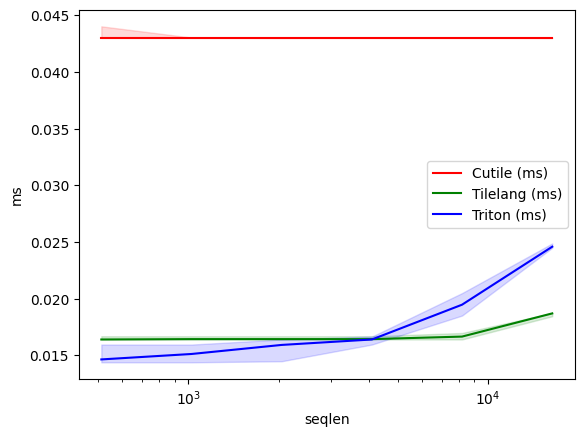

,seqlen,Cutile (ms),Tilelang (ms),Triton (ms)
0,512.0,0.043008,0.016384,0.014624
1,1024.0,0.043008,0.016416,0.015104
2,2048.0,0.043008,0.016416,0.015904
3,4096.0,0.043008,0.016416,0.016384
4,8192.0,0.043008,0.016640,0.019456
5,16384.0,0.043008,0.018688,0.024576


In [8]:
benchmark_sinkhorn_fwd.run(show_plots=True, return_df=True)

In [9]:
@triton.testing.perf_report(_make_bench(f'mhc-aggregate-fwd-C{HIDDEN}'))
def benchmark_aggregate_fwd(seqlen, provider):
    return _run_and_time(
        build_aggregate_fwd(provider, seqlen, BATCH, N_STREAMS, HIDDEN, DTYPE)
    )

2026-04-24 01:20:23  [TileLang:tilelang.jit.kernel:INFO] (kernel.py:133): TileLang begins to compile kernel `_mhc_pre_apply_mix_fwd_kernel` with `out_idx=None`
2026-04-24 01:20:26  [TileLang:tilelang.jit.kernel:INFO] (kernel.py:141): TileLang completes to compile kernel `_mhc_pre_apply_mix_fwd_kernel`


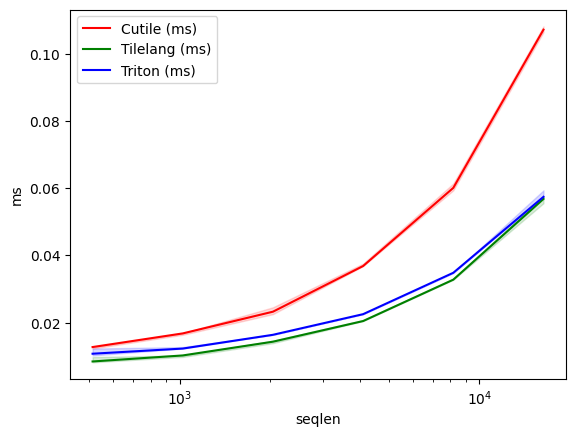

,seqlen,Cutile (ms),Tilelang (ms),Triton (ms)
0,512.0,0.012736,0.008448,0.010752
1,1024.0,0.016800,0.010240,0.012288
2,2048.0,0.023264,0.014336,0.016384
3,4096.0,0.036864,0.020480,0.022528
4,8192.0,0.060128,0.032800,0.034848
5,16384.0,0.107232,0.056832,0.057456


In [10]:
benchmark_aggregate_fwd.run(show_plots=True, return_df=True)

In [11]:
@triton.testing.perf_report(_make_bench(f'mhc-expand_combine-fwd-C{HIDDEN}'))
def benchmark_expand_combine_fwd(seqlen, provider):
    return _run_and_time(
        build_expand_combine_fwd(provider, seqlen, BATCH, N_STREAMS, HIDDEN, DTYPE)
    )


2026-04-24 01:24:56  [TileLang:tilelang.jit.kernel:INFO] (kernel.py:133): TileLang begins to compile kernel `_mhc_post_fwd_kernel` with `out_idx=None`
2026-04-24 01:24:59  [TileLang:tilelang.jit.kernel:INFO] (kernel.py:141): TileLang completes to compile kernel `_mhc_post_fwd_kernel`


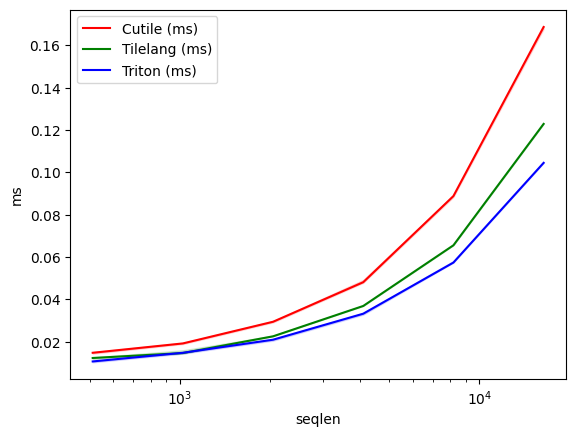

,seqlen,Cutile (ms),Tilelang (ms),Triton (ms)
0,512.0,0.014752,0.012288,0.010656
1,1024.0,0.019168,0.014624,0.014752
2,2048.0,0.029408,0.022528,0.020928
3,4096.0,0.048096,0.036864,0.033216
4,8192.0,0.088800,0.065536,0.057376
5,16384.0,0.168672,0.122880,0.104480


In [12]:
benchmark_expand_combine_fwd.run(show_plots=True, return_df=True)

In [13]:
@triton.testing.perf_report(_make_bench(f'mhc-projection-fwd-C{HIDDEN}'))
def benchmark_projection_fwd(seqlen, provider):
    return _run_and_time(
        build_projection_fwd(provider, seqlen, BATCH, N_STREAMS, HIDDEN, DTYPE)
    )


2026-04-24 01:27:05  [TileLang:tilelang.jit.kernel:INFO] (kernel.py:133): TileLang begins to compile kernel `_mhc_pre_norm_fn_fwd_mul_kernel` with `out_idx=None`
2026-04-24 01:27:09  [TileLang:tilelang.jit.kernel:INFO] (kernel.py:141): TileLang completes to compile kernel `_mhc_pre_norm_fn_fwd_mul_kernel`
2026-04-24 01:27:09  [TileLang:tilelang.jit.kernel:INFO] (kernel.py:133): TileLang begins to compile kernel `_mhc_pre_norm_fn_fwd_norm_kernel` with `out_idx=None`
2026-04-24 01:27:12  [TileLang:tilelang.jit.kernel:INFO] (kernel.py:141): TileLang completes to compile kernel `_mhc_pre_norm_fn_fwd_norm_kernel`


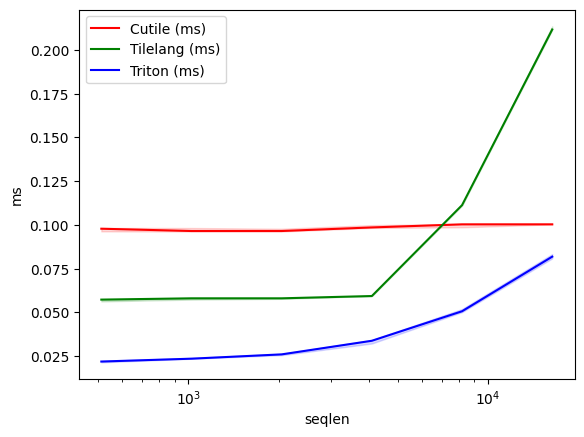

,seqlen,Cutile (ms),Tilelang (ms),Triton (ms)
0,512.0,0.097856,0.057344,0.021952
1,1024.0,0.096544,0.058080,0.023584
2,2048.0,0.096544,0.058080,0.026048
3,4096.0,0.098592,0.059392,0.033824
4,8192.0,0.100352,0.111328,0.050688
5,16384.0,0.100352,0.211712,0.081888


In [14]:
benchmark_projection_fwd.run(show_plots=True, return_df=True)

In [15]:
@triton.testing.perf_report(_make_bench(f'mhc-sinkhorn-bwd-C{HIDDEN}'))
def benchmark_sinkhorn_bwd(seqlen, provider):
    return _run_and_time(
        build_sinkhorn_bwd(provider, seqlen, BATCH, N_STREAMS, SINKHORN_ITERS)
    )

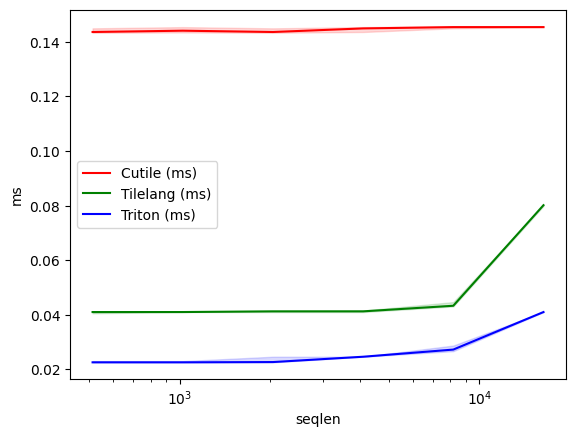

,seqlen,Cutile (ms),Tilelang (ms),Triton (ms)
0,512.0,0.143616,0.040960,0.022528
1,1024.0,0.144096,0.040960,0.022528
2,2048.0,0.143616,0.041216,0.022624
3,4096.0,0.144928,0.041216,0.024576
4,8192.0,0.145408,0.043264,0.027200
5,16384.0,0.145408,0.080128,0.040960


In [16]:
benchmark_sinkhorn_bwd.run(show_plots=True, return_df=True)

In [17]:
@triton.testing.perf_report(_make_bench(f'mhc-aggregate-bwd-C{HIDDEN}'))
def benchmark_aggregate_bwd(seqlen, provider):
    return _run_and_time(
        build_aggregate_bwd(provider, seqlen, BATCH, N_STREAMS, HIDDEN, DTYPE)
    )

In [18]:
benchmark_aggregate_bwd.run(show_plots=True, return_df=True)

2026-04-24 01:28:08  [TileLang:tilelang.jit.kernel:INFO] (kernel.py:133): TileLang begins to compile kernel `_mhc_pre_apply_mix_bwd_kernel` with `out_idx=[4]`
2026-04-24 01:28:13  [TileLang:tilelang.jit.kernel:INFO] (kernel.py:141): TileLang completes to compile kernel `_mhc_pre_apply_mix_bwd_kernel`


KeyboardInterrupt: 

In [ ]:
@triton.testing.perf_report(_make_bench(f'mhc-expand_combine-bwd-C{HIDDEN}'))
def benchmark_expand_combine_bwd(seqlen, provider):
    return _run_and_time(
        build_expand_combine_bwd(provider, seqlen, BATCH, N_STREAMS, HIDDEN, DTYPE)
    )

2026-04-24 01:15:33  [TileLang:tilelang.jit.kernel:INFO] (kernel.py:133): TileLang begins to compile kernel `_mhc_post_bwd_kernel` with `out_idx=[5, 6, 7, 8]`
2026-04-24 01:15:46  [TileLang:tilelang.jit.kernel:INFO] (kernel.py:141): TileLang completes to compile kernel `_mhc_post_bwd_kernel`


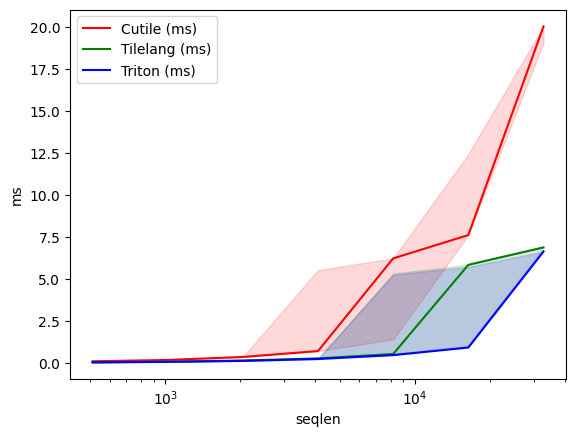

,seqlen,Cutile (ms),Tilelang (ms),Triton (ms)
0,512.0,0.108832,0.047584,0.047136
1,1024.0,0.188448,0.086464,0.075808
2,2048.0,0.366624,0.156128,0.132672
3,4096.0,0.717088,0.280608,0.245792
4,8192.0,6.229456,0.543232,0.476448
5,16384.0,7.617888,5.846784,0.929792
6,32768.0,20.027361,6.884864,6.642688


In [ ]:
benchmark_expand_combine_bwd.run(show_plots=True, return_df=True)

In [ ]:
@triton.testing.perf_report(_make_bench(f'mhc-projection-bwd-C{HIDDEN}'))
def benchmark_projection_bwd(seqlen, provider):
    return _run_and_time(
        build_projection_bwd(provider, seqlen, BATCH, N_STREAMS, HIDDEN, DTYPE)
    )

2026-04-24 01:17:39  [TileLang:tilelang.jit.kernel:INFO] (kernel.py:133): TileLang begins to compile kernel `_mhc_pre_norm_fn_bwd_norm_kernel` with `out_idx=None`
2026-04-24 01:17:42  [TileLang:tilelang.jit.kernel:INFO] (kernel.py:141): TileLang completes to compile kernel `_mhc_pre_norm_fn_bwd_norm_kernel`
2026-04-24 01:17:42  [TileLang:tilelang.jit.kernel:INFO] (kernel.py:133): TileLang begins to compile kernel `_mhc_pre_norm_fn_bwd_mul_kernel` with `out_idx=None`
2026-04-24 01:17:47  [TileLang:tilelang.jit.kernel:INFO] (kernel.py:141): TileLang completes to compile kernel `_mhc_pre_norm_fn_bwd_mul_kernel`


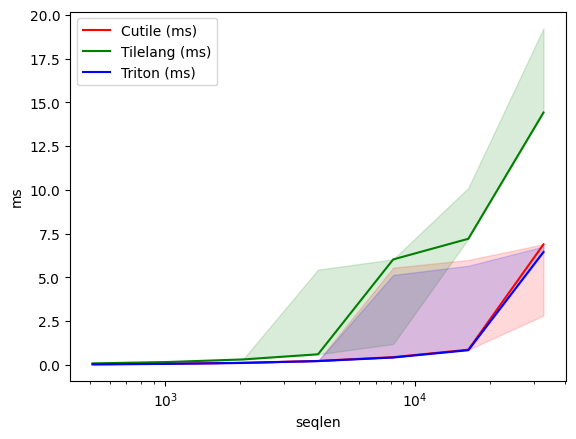

,seqlen,Cutile (ms),Tilelang (ms),Triton (ms)
0,512.0,0.045280,0.092192,0.038944
1,1024.0,0.073312,0.170864,0.065952
2,2048.0,0.127008,0.318496,0.119808
3,4096.0,0.231744,0.612384,0.225280
4,8192.0,0.448480,6.028816,0.429024
5,16384.0,0.872448,7.208992,0.848416
6,32768.0,6.889792,14.419504,6.453520


In [ ]:
benchmark_projection_bwd.run(show_plots=True, return_df=True)